### Import Libraries.

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

### Define the state.

In [33]:
# define the state.
class BatsmanState(TypedDict):
    runs : int 
    balls : int 
    fours : int 
    sixes : int 

    strike_rate : float 
    ball_per_boundary : float
    boundary_percentage_runs : float
    summary : str 

### Define the nodes/function for each task.

In [34]:
# define the calculate strike rate node.
def calculate_strike_rate(state : BatsmanState):

    strike_rate = (state['runs'] / state['balls']) * 100

    # Instead of updating the state, we just return the partial state, which is update here in this node
    # state['strike_rate'] = strike_rate

    return {
        'strike_rate' : strike_rate
    }

In [35]:
# define the calculate ball per boundary node.
def calculate_ball_per_boundary(state : BatsmanState): 

    balls_faced = state['balls']
    boundaries = state['fours'] + state['sixes']

    ball_per_boundary = balls_faced / boundaries

    # Instead of updating the state, we just return the partial state, which is update here in this node
    # state['ball_per_boundary'] = ball_per_boundary

    return {
        'ball_per_boundary' : ball_per_boundary
    }

In [36]:
# define the boundary percentage runs node. 
def calculate_boundary_percentage_runs(state : BatsmanState):

    total_runs = state['runs']
    runs_by_boundary = (state['fours'] * 4) + (state['sixes'] * 6)

    boundary_percentage_runs = (runs_by_boundary / total_runs) * 100

    # Instead of updating the state, we just return the partial state, which is update here in this node
    # state['boundary_percentage_runs'] = boundary_percentage_runs

    return {
        'boundary_percentage_runs' : boundary_percentage_runs
    }

In [37]:
# define the summary node. 
def summary(state : BatsmanState): 
    summary = f"""
                Strike Rate of the batsman is {state['strike_rate']} \n
                Balls per boundary is {state['ball_per_boundary']} \n 
                Boundary Percentage Runs is {state['boundary_percentage_runs']}
        """

    # Instead of updating the state, we just return the partial state, which is update here in this node
    # state['summary'] = summary

    return {
        'summary' : summary
    }

In [38]:
# define the graph. 
graph = StateGraph(BatsmanState)

# add the nodes in the graph. 
graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_ball_per_boundary', calculate_ball_per_boundary)
graph.add_node('calculate_boundary_percentage_runs', calculate_boundary_percentage_runs)
graph.add_node('summary', summary) 

# add the edges in the graph.
graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_ball_per_boundary')
graph.add_edge(START, 'calculate_boundary_percentage_runs')


graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_ball_per_boundary', 'summary') 
graph.add_edge('calculate_boundary_percentage_runs', 'summary')

graph.add_edge('summary', END)


# compile the graph.
workflow = graph.compile()

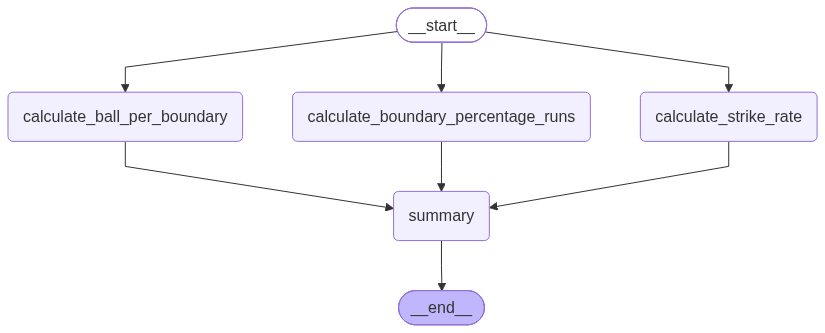

In [39]:
workflow

In [40]:
# define the initial state.
initial_state = {
    'runs' : 100, 
    'balls' : 50, 
    'fours' : 6, 
    'sixes' : 4
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'strike_rate': 200.0, 'ball_per_boundary': 5.0, 'boundary_percentage_runs': 48.0, 'summary': '\n                Strike Rate of the batsman is 200.0 \n\n                Balls per boundary is 5.0 \n \n                Boundary Percentage Runs is 48.0\n        '}
